# 04 - Full-Night REST Completeness Feasibility

Checkpoint 3: inspect the latest partitioned public REST feasibility run. This notebook reads saved artifacts only and does not make live API calls.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

latest_path = ROOT / "outputs" / "full_night_feasibility" / "latest_run.json"
if not latest_path.exists():
    raise FileNotFoundError("Run scripts/run_full_night_feasibility.py before opening this notebook.")

latest = json.loads(latest_path.read_text())
raw_dir = Path(latest["raw_dir"])
processed_dir = Path(latest["processed_dir"])
output_dir = Path(latest["output_dir"])
latest

{'manifest': '/Users/darim_shamsi/Documents/Fink Analysis/outputs/full_night_feasibility/20260624T051005Z/manifest.json',
 'output_dir': '/Users/darim_shamsi/Documents/Fink Analysis/outputs/full_night_feasibility/20260624T051005Z',
 'processed_dir': '/Users/darim_shamsi/Documents/Fink Analysis/data/processed/full_night_feasibility/20260624T051005Z',
 'raw_dir': '/Users/darim_shamsi/Documents/Fink Analysis/data/raw/full_night_feasibility/20260624T051005Z',
 'report': '/Users/darim_shamsi/Documents/Fink Analysis/outputs/full_night_feasibility/20260624T051005Z/FULL_NIGHT_FEASIBILITY_REPORT.md',
 'run_id': '20260624T051005Z'}

## Target UTC Window

In [2]:
manifest = json.loads((output_dir / "manifest.json").read_text())
config = manifest["config"]
pd.DataFrame([
    {"field": "target_startdate", "value": config.get("target_startdate")},
    {"field": "target_stopdate", "value": config.get("target_stopdate")},
    {"field": "timezone", "value": config.get("timezone")},
    {"field": "date_window_convention", "value": config.get("api_date_window_convention")},
    {"field": "min_lsst_alert_date_utc", "value": config.get("min_lsst_alert_date_utc")},
])

,field,value
0,target_startdate,2026-02-25
1,target_stopdate,2026-02-26
2,timezone,UTC
3,date_window_convention,UTC calendar dates; stopdate assumed exclusive...
4,min_lsst_alert_date_utc,2026-02-25


## Capability Diagnosis

In [3]:
capability = json.loads((output_dir / "capability_diagnosis.json").read_text())
pd.DataFrame([
    {"question": "all-alert enumeration supported", "answer": capability["all_alert_completeness"]["public_rest_enumeration_supported"]},
    {"question": "tag-specific enumeration supported", "answer": capability["tag_specific_completeness"]["public_rest_enumeration_supported"]},
    {"question": "pagination exposed", "answer": capability["pagination_exposed"]},
    {"question": "row caps exposed", "answer": capability["row_caps_exposed"]},
])

,question,answer
0,all-alert enumeration supported,False
1,tag-specific enumeration supported,True
2,pagination exposed,False
3,row caps exposed,True


In [4]:
endpoint_rows = []
for path, row in capability["endpoints"].items():
    endpoint_rows.append({
        "endpoint": path,
        "row_cap": row["supports_row_cap"],
        "pagination": row["supports_pagination"],
        "date_filter": row["supports_date_filter"],
        "tag_filter": row["supports_tag_filter"],
        "band_filter": row["supports_band_filter"],
        "sky_filter": row["supports_sky_filter"],
        "known_id": row["requires_known_object_id"],
    })
pd.DataFrame(endpoint_rows)

,endpoint,row_cap,pagination,date_filter,tag_filter,band_filter,sky_filter,known_id
0,/api/v1/conesearch,True,False,True,False,False,True,False
1,/api/v1/fp,False,False,False,False,False,False,True
2,/api/v1/objects,False,False,False,False,False,False,True
3,/api/v1/sources,False,False,False,False,False,False,True
4,/api/v1/statistics,False,False,True,False,False,False,False
5,/api/v1/tags,True,False,True,True,False,False,False


## Partition Strategy And Results

In [5]:
plan = json.loads((output_dir / "partition_plan.json").read_text())
pd.DataFrame([
    {"field": "strategy", "value": plan.get("strategy")},
    {"field": "completeness_scope", "value": plan.get("completeness_scope")},
    {"field": "target_tag", "value": plan.get("target_tag")},
    {"field": "partition_count", "value": plan.get("partition_count")},
    {"field": "unsupported_dimensions", "value": plan.get("unsupported_dimensions")},
])

,field,value
0,strategy,auto
1,completeness_scope,tag_specific
2,target_tag,in_tns
3,partition_count,96
4,unsupported_dimensions,[band]


In [6]:
results = pd.DataFrame(json.loads((output_dir / "partition_results.json").read_text()))
display_columns = [column for column in ["partition_id", "status", "row_count", "requested_n", "startdate", "stopdate", "target_tag", "message"] if column in results.columns]
results[display_columns]

,partition_id,status,row_count,requested_n,startdate,stopdate,target_tag,message
0,refined_time_000,empty,0,50,2026-02-25,2026-02-25T00:15:00Z,in_tns,Partition returned zero rows
1,refined_time_001,empty,0,50,2026-02-25T00:15:00Z,2026-02-25T00:30:00Z,in_tns,Partition returned zero rows
2,refined_time_002,exhausted,36,50,2026-02-25T00:30:00Z,2026-02-25T00:45:00Z,in_tns,Partition returned fewer rows than requested cap
3,refined_time_003,exhausted,47,50,2026-02-25T00:45:00Z,2026-02-25T01:00:00Z,in_tns,Partition returned fewer rows than requested cap
4,refined_time_004,exhausted,39,50,2026-02-25T01:00:00Z,2026-02-25T01:15:00Z,in_tns,Partition returned fewer rows than requested cap
...,...,...,...,...,...,...,...,...
91,refined_time_091,empty,0,50,2026-02-25T22:45:00Z,2026-02-25T23:00:00Z,in_tns,Partition returned zero rows
92,refined_time_092,empty,0,50,2026-02-25T23:00:00Z,2026-02-25T23:15:00Z,in_tns,Partition returned zero rows
93,refined_time_093,empty,0,50,2026-02-25T23:15:00Z,2026-02-25T23:30:00Z,in_tns,Partition returned zero rows
94,refined_time_094,empty,0,50,2026-02-25T23:30:00Z,2026-02-25T23:45:00Z,in_tns,Partition returned zero rows


In [7]:
results.loc[results["status"].eq("possibly_truncated"), display_columns]

,partition_id,status,row_count,requested_n,startdate,stopdate,target_tag,message
12,refined_time_012,possibly_truncated,50,50,2026-02-25T03:00:00Z,2026-02-25T03:15:00Z,in_tns,Partition returned the requested row cap
13,refined_time_013,possibly_truncated,50,50,2026-02-25T03:15:00Z,2026-02-25T03:30:00Z,in_tns,Partition returned the requested row cap
14,refined_time_014,possibly_truncated,50,50,2026-02-25T03:30:00Z,2026-02-25T03:45:00Z,in_tns,Partition returned the requested row cap
15,refined_time_015,possibly_truncated,50,50,2026-02-25T03:45:00Z,2026-02-25T04:00:00Z,in_tns,Partition returned the requested row cap
16,refined_time_016,possibly_truncated,50,50,2026-02-25T04:00:00Z,2026-02-25T04:15:00Z,in_tns,Partition returned the requested row cap
17,refined_time_017,possibly_truncated,50,50,2026-02-25T04:15:00Z,2026-02-25T04:30:00Z,in_tns,Partition returned the requested row cap
18,refined_time_018,possibly_truncated,50,50,2026-02-25T04:30:00Z,2026-02-25T04:45:00Z,in_tns,Partition returned the requested row cap
19,refined_time_019,possibly_truncated,50,50,2026-02-25T04:45:00Z,2026-02-25T05:00:00Z,in_tns,Partition returned the requested row cap
20,refined_time_020,possibly_truncated,50,50,2026-02-25T05:00:00Z,2026-02-25T05:15:00Z,in_tns,Partition returned the requested row cap
21,refined_time_021,possibly_truncated,50,50,2026-02-25T05:15:00Z,2026-02-25T05:30:00Z,in_tns,Partition returned the requested row cap


## Deduplication And Denominator Accounting

In [8]:
accounting = json.loads((output_dir / "completeness_accounting.json").read_text())
pd.DataFrame([
    {"metric": "extracted_count", "value": accounting.get("extracted_count")},
    {"metric": "denominator_available", "value": accounting.get("denominator_available")},
    {"metric": "denominator_type", "value": accounting.get("denominator_type")},
    {"metric": "directly_comparable", "value": accounting.get("directly_comparable")},
    {"metric": "completeness_fraction", "value": accounting.get("completeness_fraction")},
    {"metric": "duplicate_rate", "value": accounting.get("deduplication", {}).get("duplicate_rate")},
])

,metric,value
0,extracted_count,1521
1,denominator_available,False
2,denominator_type,unknown
3,directly_comparable,False
4,completeness_fraction,None
5,duplicate_rate,0.0


## Diagnostics

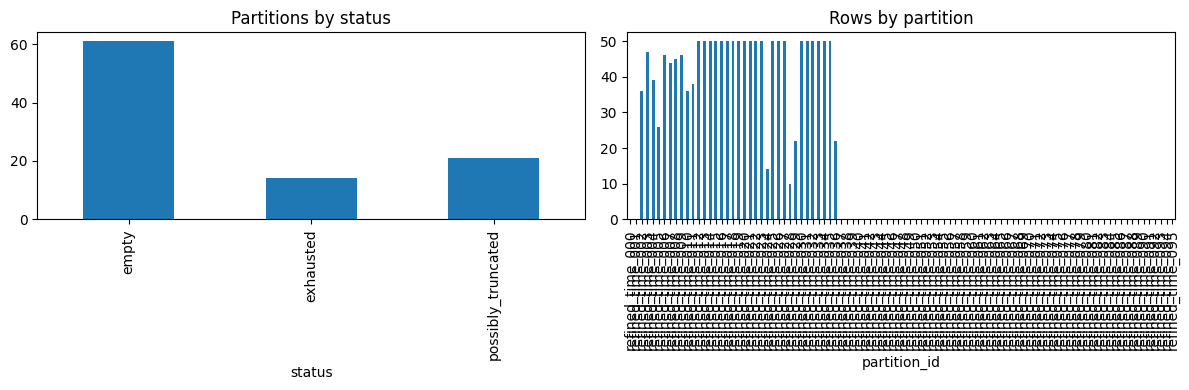

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
results.groupby("status").size().plot(kind="bar", ax=axes[0], title="Partitions by status")
if "row_count" in results.columns:
    results.plot(x="partition_id", y="row_count", kind="bar", ax=axes[1], legend=False, title="Rows by partition")
    axes[1].tick_params(axis="x", labelrotation=90)
plt.tight_layout()

(1521, 142)


,f:clf_cats_class,f:clf_cats_score,f:clf_earlySNIa_score,f:clf_elephant_kstest_science,f:clf_elephant_kstest_template,f:clf_snnSnVsOthers_score,f:fink_broker_version,f:fink_science_version,f:lsst_schema_version,f:xm_gaiadr3_DR3Name,...,internal_object_id,internal_source_id,ra,dec,time_mjd,band,flux,flux_err,class_label,_unmapped_fields
0,11,1.000000,-1.0,NaN,NaN,0.034380,4.1,8.39.0,lsst.v10_0,None,...,313853501446815761,170054918401949744,64.284150,-46.529279,61096.030943,i,5094.5957,213.56874,11,"[""f:clf_cats_score"", ""f:clf_earlySNIa_score"", ..."
1,21,0.999817,-1.0,NaN,NaN,0.147355,4.1,8.39.0,lsst.v10_0,None,...,170028487021691019,170054918378356894,65.080183,-46.933159,61096.030943,i,-35412.6560,268.16350,21,"[""f:clf_cats_score"", ""f:clf_earlySNIa_score"", ..."
2,11,0.999999,-1.0,NaN,NaN,0.023603,4.1,8.39.0,lsst.v10_0,None,...,313637935719645190,170054918296043696,58.986991,-48.120584,61096.030462,i,-12057.0650,268.20786,11,"[""f:clf_cats_score"", ""f:clf_earlySNIa_score"", ..."
3,11,0.991570,-1.0,NaN,NaN,0.183634,4.1,8.39.0,lsst.v10_0,None,...,170028485646483572,170054918221070489,62.151389,-49.001440,61096.030462,i,-20416.6970,247.74396,11,"[""f:clf_cats_score"", ""f:clf_earlySNIa_score"", ..."
4,11,0.991623,-1.0,NaN,NaN,0.183386,4.1,8.39.0,lsst.v10_0,None,...,170028485646483572,170054918104154268,62.151386,-49.001441,61096.030031,i,-19759.6150,225.65746,11,"[""f:clf_cats_score"", ""f:clf_earlySNIa_score"", ..."


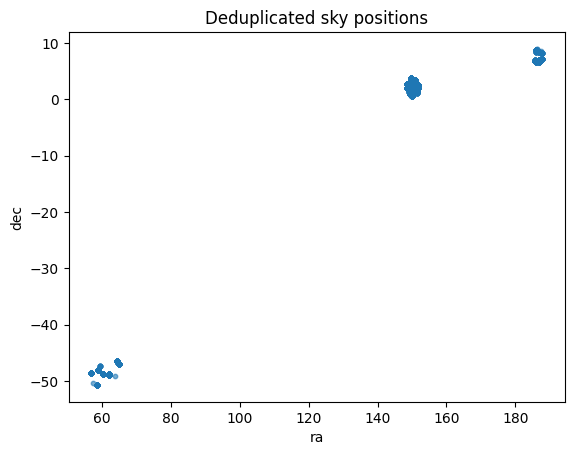

In [10]:
parquet_path = processed_dir / "deduplicated_rows.parquet"
if parquet_path.exists():
    rows = pd.read_parquet(parquet_path)
    print(rows.shape)
    display(rows.head())
    if {"ra", "dec"}.issubset(rows.columns):
        rows.plot.scatter(x="ra", y="dec", s=10, alpha=0.6, title="Deduplicated sky positions")
else:
    print("No deduplicated rows were written for this run.")

## Validation And Decision

In [11]:
validation = pd.DataFrame(json.loads((output_dir / "validation_report.json").read_text())["checks"])
validation.groupby(["severity", "passed"]).size().rename("count").reset_index()

,severity,passed,count
0,error,True,18
1,info,True,5


In [12]:
validation.loc[~validation["passed"], [column for column in ["severity", "table", "check", "message"] if column in validation.columns]]

,severity,table,check,message


In [13]:
decision = json.loads((output_dir / "full_night_decision.json").read_text())
pd.DataFrame([
    {"field": "rest_full_night_complete", "value": decision.get("rest_full_night_complete")},
    {"field": "data_transfer_should_be_considered", "value": decision.get("data_transfer_should_be_considered")},
    {"field": "next_required_action", "value": decision.get("next_required_action")},
])

,field,value
0,rest_full_night_complete,unresolved
1,data_transfer_should_be_considered,True
2,next_required_action,Find documented pagination/continuation or a s...


In [14]:
print("Blockers:")
for blocker in decision.get("blockers", []):
    print(f"- {blocker}")

print("\nREST remains useful for:")
for item in decision.get("rest_still_useful_for", []):
    print(f"- {item}")

Blockers:
- No public REST all-alert enumeration path was proven.
- The executed extraction scope was not all-alert.
- At least one partition was failed, skipped, unsupported, unsafe, or possibly truncated.
- No directly comparable denominator is available.

REST remains useful for:
- candidate-level lookup
- bounded tag/date-window samples
- known-ID object/source/forced-photometry enrichment


## Scientific Interpretation

- REST proves full-night all-alert completeness only if the final decision is `yes`.
- Capped, failed, unsupported, skipped, or unsafe partitions prevent a completeness claim.
- Tag-specific extraction is not all-alert extraction.
- Non-matching statistics are context, not a denominator.
- Bounded/candidate REST products can still support careful candidate-level and method-development work, but incomplete rows must not drive population-level astrophysical conclusions.